# IEMOCAP Benchmark: Proposed Cascade vs Three Competitors

**Задача:** сравнить предложенную каскадную мультимодальную архитектуру с тремя конкурентами на IEMOCAP.

## Предложенная модель (cascade)
- **Audio gate:** Log-Mel + `MelCNN` — бинарная классификация *neutral vs non-neutral* (предобучена на RAVDESS+CREMA-D).
- **Video branch:** MediaPipe face detection → EmotiEffNet (`enet_b0_8_best_vgaf`, 1280-dim) → `BiLSTMClassifier` → 6 эмоций.
- **Fusion:** если audio-gate = neutral → итог = neutral; иначе — argmax видео-ветки.

## Конкуренты (упрощённые реализации)
1. **SCME + GF** — Sparse Cross-Modal Encoder + Gated Fusion *(2024)*. Упрощение: transformer + cross-attention между wav2vec2 и EmotiEffNet, затем gated fusion.
2. **MM-NodeFormer** — Interspeech 2024. Упрощение: два потока transformer-энкодеров + cross-modal attention на нескольких слоях + mean-pool + classifier.
3. **ResNet18 + GRU** — baseline (arXiv 2023). ResNet18 признаки per-frame + GRU.

## Датасет
IEMOCAP full release. 6 классов: `neutral, happy, sad, angry, excited, frustrated`.
Спикер-независимый сплит: **Session 1–4 → train**, **Session 5 → test**.

RAVDESS emotions: 01 = neutral, 02 = calm, 03 = happy, 04 = sad, 05 = angry, 06 = fearful, 07 = disgust, 08 = surprised

## Метрики
Accuracy, Weighted F1, inference time (мс/сэмпл), размер модели (MB).


## 1. Установка зависимостей и конфиг

In [107]:
import os, json, time, gc, warnings, pickle, math
warnings.filterwarnings('ignore')
from pathlib import Path

import numpy as np
import pandas as pd
import cv2
import librosa
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.models as tv_models
import torchvision.transforms as T

from sklearn.metrics import (accuracy_score, f1_score, confusion_matrix,
                             classification_report)
from sklearn.utils.class_weight import compute_class_weight

device = torch.device('cuda' if torch.cuda.is_available()
                      else ('mps' if torch.backends.mps.is_available() else 'cpu'))
print('Device:', device)

# --- пути
IEMOCAP_ROOT      = '../datasets/IEMOCAP_full_release'
IEMOCAP_META_CSV  = '../datasets/iemocap_processed/metadata.csv'
CACHE_DIR         = Path('../datasets/iemocap_features_cache')
CACHE_DIR.mkdir(parents=True, exist_ok=True)

AUDIO_CKPT_DIR    = '../trained_models/audio_neutral_2'
VIDEO_CKPT_DIR    = '../trained_models/video_emotion_2'
CKPT_OUT_DIR      = Path('../trained_models/iemocap_benchmark')
CKPT_OUT_DIR.mkdir(parents=True, exist_ok=True)

FACE_DETECTOR_PATH = '../raw_models/blaze_face_short_range.tflite'

# --- параметры
SR        = 16_000
N_MELS    = 64
MAX_LEN   = 128       # mel-фреймов
HOP       = 512
N_FRAMES  = 16        # видео-кадров на реплику
IMG_SIZE  = 224
FEAT_EFF  = 1280      # EmotiEffNet
FEAT_RES  = 512       # ResNet18
FEAT_W2V  = 768       # wav2vec2-base

LABELS_6 = ['neutral', 'happy', 'sad', 'angry', 'excited', 'frustrated']
RAW2IDX  = {'neu': 0, 'hap': 1, 'sad': 2, 'ang': 3, 'exc': 4, 'fru': 5}
N_CLS    = len(LABELS_6)

SEED = 42
torch.manual_seed(SEED); np.random.seed(SEED)

def size_mb(model):
    b = sum(p.numel() * p.element_size() for p in model.parameters())
    b += sum(x.numel() * x.element_size() for x in model.buffers())
    return b / 1024**2

Device: mps


## 2. Загрузка метаданных IEMOCAP

Фильтруем реплики по 6 эмоциональным классам (`neu, hap, sad, ang, exc, fru`), разбиваем по сессиям.


In [108]:
meta = pd.read_csv(IEMOCAP_META_CSV)

def avi_path(row):
    return os.path.join(IEMOCAP_ROOT, row['session'], 'dialog', 'avi', 'DivX',
                        f"{row['dialog']}.avi")

meta['avi_path'] = meta.apply(avi_path, axis=1)
meta = meta[meta['emotion_raw'].isin(RAW2IDX)].reset_index(drop=True)
meta['label6'] = meta['emotion_raw'].map(RAW2IDX)

# speaker-independent split: Session 1-4 train / Session 5 test
meta['split'] = np.where(meta['session'] == 'Session5', 'test', 'train')

print(f'Всего реплик: {len(meta)} | train: {(meta.split == "train").sum()} | '
      f'test: {(meta.split == "test").sum()}')
print('\nРаспределение по классам:')
print(meta.groupby(['split', 'emotion_raw']).size().unstack(fill_value=0))

Всего реплик: 5531 | train: 4290 | test: 1241

Распределение по классам:
emotion_raw  ang  exc  hap   neu  sad
split                                
test         170  299  143   384  245
train        933  742  452  1324  839


## 3. Инициализация фич-экстракторов

- **EmotiEffNet** через `emotiefflib` — backbone `enet_b0_8_best_vgaf`, `.classifier = Identity` → 1280-dim.
- **ResNet18** ImageNet-pretrained, avgpool → 512-dim.
- **Wav2Vec2-base-960h** — 768-dim sequence; усредним по 16 равным чанкам.
- **MediaPipe FaceDetector** — для кропов лица.


In [109]:
from emotiefflib.facial_analysis import EmotiEffLibRecognizer

_eff_rec = EmotiEffLibRecognizer(engine='torch',
                                 model_name='enet_b0_8_best_vgaf',
                                 device=str(device))
emotieffnet = _eff_rec.model.to(device).eval()
for p in emotieffnet.parameters(): p.requires_grad_(False)

# ResNet18 ImageNet frozen
resnet18 = tv_models.resnet18(weights=tv_models.ResNet18_Weights.DEFAULT)
resnet18.fc = nn.Identity()
resnet18 = resnet18.to(device).eval()
for p in resnet18.parameters(): p.requires_grad_(False)

# Wav2Vec2
from transformers import Wav2Vec2Model, Wav2Vec2FeatureExtractor
W2V_NAME = 'facebook/wav2vec2-base-960h'
w2v_proc = Wav2Vec2FeatureExtractor.from_pretrained(W2V_NAME)
w2v_model = Wav2Vec2Model.from_pretrained(W2V_NAME).to(device).eval()
for p in w2v_model.parameters(): p.requires_grad_(False)

# MediaPipe face detector
import mediapipe as mp
from mediapipe.tasks import python as mp_python
from mediapipe.tasks.python import vision as mp_vision
_face_detector = mp_vision.FaceDetector.create_from_options(
    mp_vision.FaceDetectorOptions(
        base_options=mp_python.BaseOptions(model_asset_path=FACE_DETECTOR_PATH),
        min_detection_confidence=0.5,
    )
)

imagenet_tf = T.Compose([
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])
print('All feature extractors ready.')

Loading weights:   0%|          | 0/210 [00:00<?, ?it/s]

Wav2Vec2Model LOAD REPORT from: facebook/wav2vec2-base-960h
Key               | Status     | 
------------------+------------+-
lm_head.weight    | UNEXPECTED | 
lm_head.bias      | UNEXPECTED | 
masked_spec_embed | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


All feature extractors ready.


I0000 00:00:1776934027.623026 23885749 gl_context.cc:407] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M1 Pro
W0000 00:00:1776934027.624343 23885752 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


## 4. Утилиты: лицо, кадры, mel, wav2vec2


In [110]:
# --- audio log-mel для MelCNN gate (mean/std подтянем из meta аудио-чекпоинта)
with open(os.path.join(AUDIO_CKPT_DIR, 'meta.json')) as f:
    _amg = json.load(f)
MEL_MEAN = _amg['mel_mean']; MEL_STD = _amg['mel_std']

def load_wav(p):
    y, _ = librosa.load(p, sr=SR, mono=True); return y

def logmel(y):
    mel = librosa.feature.melspectrogram(y=y, sr=SR, n_mels=N_MELS, hop_length=HOP)
    lm  = librosa.power_to_db(mel, ref=np.max)
    if lm.shape[1] < MAX_LEN:
        lm = np.pad(lm, ((0, 0), (0, MAX_LEN - lm.shape[1])))
    else:
        lm = lm[:, :MAX_LEN]
    lm = (lm - MEL_MEAN) / (MEL_STD + 1e-8)
    return lm.astype(np.float32)         # (64, 128)

@torch.no_grad()
def wav2vec2_feat(y, n_chunks=N_FRAMES):
    inp = w2v_proc(y, sampling_rate=SR, return_tensors='pt').input_values.to(device)
    out = w2v_model(inp).last_hidden_state[0].cpu().numpy()   # (T, 768)
    T_ = out.shape[0]
    if T_ >= n_chunks:
        idx = np.linspace(0, T_, n_chunks + 1, dtype=int)
        feats = np.stack([out[idx[i]:idx[i+1]].mean(0) for i in range(n_chunks)])
    else:
        feats = np.pad(out, ((0, n_chunks - T_), (0, 0)))
    return feats.astype(np.float32)      # (16, 768)

def speaker_side(utt_id):
    head = utt_id.split('_')[0]
    first = head[-1]
    spk = utt_id.split('_')[-1][0]
    return 'L' if spk == first else 'R'

def crop_half(frame, lr):
    w = frame.shape[1]; mid = w // 2
    return frame[:, :mid] if lr == 'L' else frame[:, mid:]

def detect_crop(frame, size=IMG_SIZE):
    mp_img = mp.Image(image_format=mp.ImageFormat.SRGB, data=frame)
    res = _face_detector.detect(mp_img)
    if res.detections:
        bb = res.detections[0].bounding_box
        h, w = frame.shape[:2]
        px = int(bb.width * 0.1); py = int(bb.height * 0.1)
        x1 = max(0, bb.origin_x - px); y1 = max(0, bb.origin_y - py)
        x2 = min(w, bb.origin_x + bb.width + px)
        y2 = min(h, bb.origin_y + bb.height + py)
        if x2 > x1 and y2 > y1:
            return cv2.resize(frame[y1:y2, x1:x2], (size, size))
    h, w = frame.shape[:2]; s = min(h, w)
    y1, x1 = (h - s)//2, (w - s)//2
    return cv2.resize(frame[y1:y1+s, x1:x1+s], (size, size))

def extract_frames(avi, start, end, n=N_FRAMES):
    cap = cv2.VideoCapture(avi)
    if not cap.isOpened(): return []
    fps = cap.get(cv2.CAP_PROP_FPS) or 25.0
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    s = max(0, int(start * fps)); e = min(total - 1, int(end * fps))
    if e <= s: e = min(total - 1, s + 1)
    idx = np.linspace(s, e, n, dtype=int)
    frames = []
    for i in idx:
        cap.set(cv2.CAP_PROP_POS_FRAMES, i)
        ok, fr = cap.read()
        if ok: frames.append(cv2.cvtColor(fr, cv2.COLOR_BGR2RGB))
    cap.release()
    return frames

@torch.no_grad()
def extract_video_feats(avi, start, end, lr):
    frames = extract_frames(avi, start, end, N_FRAMES)
    if not frames:
        crops = [np.zeros((IMG_SIZE, IMG_SIZE, 3), np.uint8)] * N_FRAMES
    else:
        while len(frames) < N_FRAMES: frames.append(frames[-1])
        crops = [detect_crop(crop_half(f, lr)) for f in frames[:N_FRAMES]]
    batch = torch.stack([imagenet_tf(c) for c in crops]).to(device)
    eff = emotieffnet(batch).cpu().numpy()       # (16, 1280)
    res = resnet18(batch).cpu().numpy()          # (16, 512)
    return eff.astype(np.float32), res.astype(np.float32)

## 5. Извлечение и кеширование признаков

Первый проход долгий (один раз на датасет). Сохраняем по утеренсу: `{video_eff, video_res, audio_w2v, audio_mel, label, split}`.


In [111]:
def cache_path(utt_id):
    return CACHE_DIR / f'{utt_id}.pt'

def extract_all(force=False):
    done, skipped = 0, 0
    for _, row in tqdm(meta.iterrows(), total=len(meta), desc='Features'):
        p = cache_path(row['utterance_id'])
        if p.exists() and not force:
            skipped += 1; continue
        try:
            y  = load_wav(row['audio_path'])
            am = logmel(y)
            aw = wav2vec2_feat(y)
            lr = speaker_side(row['utterance_id'])
            ve, vr = extract_video_feats(row['avi_path'], row['start'], row['end'], lr)
            torch.save({
                'video_eff': torch.from_numpy(ve),
                'video_res': torch.from_numpy(vr),
                'audio_w2v': torch.from_numpy(aw),
                'audio_mel': torch.from_numpy(am),
                'label':     int(row['label6']),
                'split':     row['split'],
                'utt_id':    row['utterance_id'],
            }, p)
            done += 1
        except Exception as e:
            print('Fail', row['utterance_id'], e)
    print(f'Extracted: {done}, skipped cached: {skipped}')

# Запустите один раз. Для повторного прогона подтяните с кеша.
extract_all(force=False)

Features: 100%|██████████| 5531/5531 [00:00<00:00, 41942.21it/s]

Extracted: 0, skipped cached: 5531


## 6. Unified Dataset / DataLoader


In [112]:
class IEMOCAPFeatDS(Dataset):
    def __init__(self, meta_df):
        self.items = meta_df['utterance_id'].tolist()
    def __len__(self): return len(self.items)
    def __getitem__(self, i):
        d = torch.load(cache_path(self.items[i]))
        return (d['audio_mel'].unsqueeze(0),   # (1, 64, 128)
                d['audio_w2v'],                # (16, 768)
                d['video_eff'],                # (16, 1280)
                d['video_res'],                # (16, 512)
                torch.tensor(d['label'], dtype=torch.long))

meta_cached = meta[meta['utterance_id'].apply(lambda u: cache_path(u).exists())].reset_index(drop=True)
train_df = meta_cached[meta_cached.split == 'train'].reset_index(drop=True)
test_df  = meta_cached[meta_cached.split == 'test'].reset_index(drop=True)
print(f'train {len(train_df)} | test {len(test_df)}')

BS = 16
train_dl = DataLoader(IEMOCAPFeatDS(train_df), batch_size=BS, shuffle=True,  num_workers=0, drop_last=True)
test_dl  = DataLoader(IEMOCAPFeatDS(test_df),  batch_size=BS, shuffle=False, num_workers=0)

# class weights (отсутствующим в train классам присваиваем вес 1.0)
present = np.unique(train_df.label6.values)
cw_present = compute_class_weight('balanced', classes=present, y=train_df.label6.values)
cw = np.ones(N_CLS, dtype=np.float32)
cw[present] = cw_present
class_weights = torch.tensor(cw, dtype=torch.float32, device=device)
print('class weights:', {LABELS_6[i]: round(float(cw[i]), 2) for i in range(N_CLS)})
missing = [LABELS_6[i] for i in range(N_CLS) if i not in present]
if missing:
    print('NB: классы отсутствуют в train:', missing)

train 4290 | test 1241
class weights: {'neutral': 0.65, 'happy': 1.9, 'sad': 1.02, 'angry': 0.92, 'excited': 1.16, 'frustrated': 1.0}
NB: классы отсутствуют в train: ['frustrated']


## 7. Модели

### 7.1 MelCNN (pretrained gate) + BiLSTMClassifier (моя модель — cascade)


In [113]:
class MelCNN(nn.Module):
    def __init__(self, n_mels=64, max_len=128):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1), nn.BatchNorm2d(16), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * (n_mels // 8) * (max_len // 8), 256),
            nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(256, 2),
        )
    def forward(self, x): return self.classifier(self.features(x))


class BiLSTMClassifier(nn.Module):
    def __init__(self, feat_dim=1280, hidden=128, n_classes=8, num_layers=1, dropout=0.3):
        super().__init__()
        self.bilstm = nn.LSTM(
            feat_dim, hidden, num_layers=num_layers,
            batch_first=True, bidirectional=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.classifier = nn.Sequential(
            nn.Linear(hidden * 2, 64),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(64, n_classes),
        )

    def forward(self, x):
        _, (h_n, _) = self.bilstm(x)
        h_forward = h_n[-2, :, :]
        h_backward = h_n[-1, :, :]
        h = torch.cat([h_forward, h_backward], dim=1)
        return self.classifier(h)


# --- load pretrained MelCNN gate
mel_gate = MelCNN(N_MELS, MAX_LEN).to(device)
mel_gate.load_state_dict(torch.load(os.path.join(AUDIO_CKPT_DIR, 'mel_cnn.pt'),
                                    map_location=device))
mel_gate.eval()
for p in mel_gate.parameters(): p.requires_grad_(False)
print('MelCNN gate loaded (frozen).')

MelCNN gate loaded (frozen).


### 7.2 SCME + GF (упрощённая реализация)

Transformer по каждому потоку + cross-attention + gated fusion.


In [114]:
class SCME_GF(nn.Module):
    """Simplified SCME+GF: transformer encoders + cross-attention + gated fusion.
    Approximation of the 2024 paper."""
    def __init__(self, d_audio=FEAT_W2V, d_video=FEAT_EFF, d_model=128,
                 n_heads=4, n_classes=N_CLS, dropout=0.3):
        super().__init__()
        self.proj_a = nn.Linear(d_audio, d_model)
        self.proj_v = nn.Linear(d_video, d_model)
        enc = lambda: nn.TransformerEncoder(
            nn.TransformerEncoderLayer(d_model, n_heads, 256, dropout,
                                       batch_first=True, activation='gelu'), 2)
        self.enc_a = enc(); self.enc_v = enc()
        self.x_av = nn.MultiheadAttention(d_model, n_heads, dropout=dropout, batch_first=True)
        self.x_va = nn.MultiheadAttention(d_model, n_heads, dropout=dropout, batch_first=True)
        self.gate = nn.Sequential(nn.Linear(2 * d_model, d_model), nn.Sigmoid())
        self.cls  = nn.Sequential(nn.Linear(d_model, 64), nn.GELU(),
                                  nn.Dropout(dropout), nn.Linear(64, n_classes))
    def forward(self, a, v):
        a = self.enc_a(self.proj_a(a))
        v = self.enc_v(self.proj_v(v))
        a2, _ = self.x_av(a, v, v)
        v2, _ = self.x_va(v, a, a)
        a2 = a2.mean(1); v2 = v2.mean(1)
        g = self.gate(torch.cat([a2, v2], dim=-1))
        fused = g * a2 + (1 - g) * v2
        return self.cls(fused)

### 7.3 MM-NodeFormer (упрощённая реализация)

Двухпоточный transformer с cross-modal attention на нескольких слоях.


In [115]:
class CrossLayer(nn.Module):
    def __init__(self, d, heads, dropout):
        super().__init__()
        self.sa_a = nn.MultiheadAttention(d, heads, dropout=dropout, batch_first=True)
        self.sa_v = nn.MultiheadAttention(d, heads, dropout=dropout, batch_first=True)
        self.ca_a = nn.MultiheadAttention(d, heads, dropout=dropout, batch_first=True)
        self.ca_v = nn.MultiheadAttention(d, heads, dropout=dropout, batch_first=True)
        self.na, self.nv = nn.LayerNorm(d), nn.LayerNorm(d)
        self.ff_a = nn.Sequential(nn.Linear(d, d*2), nn.GELU(), nn.Linear(d*2, d))
        self.ff_v = nn.Sequential(nn.Linear(d, d*2), nn.GELU(), nn.Linear(d*2, d))
    def forward(self, a, v):
        a = a + self.sa_a(a, a, a)[0]
        v = v + self.sa_v(v, v, v)[0]
        a2 = a + self.ca_a(a, v, v)[0]
        v2 = v + self.ca_v(v, a, a)[0]
        a = self.na(a2 + self.ff_a(a2))
        v = self.nv(v2 + self.ff_v(v2))
        return a, v


class MM_NodeFormer(nn.Module):
    """Simplified MM-NodeFormer (Interspeech 2024): two-stream transformer
    with cross-modal attention at multiple layers + mean-pool + MLP."""
    def __init__(self, d_audio=FEAT_W2V, d_video=FEAT_EFF, d_model=128,
                 n_heads=4, n_layers=3, n_classes=N_CLS, dropout=0.3):
        super().__init__()
        self.proj_a = nn.Linear(d_audio, d_model)
        self.proj_v = nn.Linear(d_video, d_model)
        self.layers = nn.ModuleList([CrossLayer(d_model, n_heads, dropout)
                                     for _ in range(n_layers)])
        self.cls = nn.Sequential(nn.Linear(2 * d_model, 128), nn.GELU(),
                                 nn.Dropout(dropout), nn.Linear(128, n_classes))
    def forward(self, a, v):
        a = self.proj_a(a); v = self.proj_v(v)
        for ly in self.layers: a, v = ly(a, v)
        return self.cls(torch.cat([a.mean(1), v.mean(1)], dim=-1))

### 7.4 ResNet18 + GRU (baseline)

ResNet18-признаки (512-dim, предвычислены) → bidirectional GRU → MLP.


In [116]:
class ResNetGRU(nn.Module):
    def __init__(self, feat_dim=FEAT_RES, hidden=128, n_classes=N_CLS, dropout=0.3):
        super().__init__()
        self.gru = nn.GRU(feat_dim, hidden, num_layers=2, batch_first=True,
                          bidirectional=True, dropout=dropout)
        self.cls = nn.Sequential(nn.Linear(hidden * 2, 64), nn.ReLU(),
                                 nn.Dropout(0.5), nn.Linear(64, n_classes))
    def forward(self, x):
        _, h = self.gru(x)
        return self.cls(torch.cat([h[-2], h[-1]], dim=-1))

## 8. Тренировочный цикл (одинаковый для всех)

AdamW, 30 эпох, batch 16, class-weighted CE + label smoothing, early stopping (patience 6) по val-F1.


In [117]:
EPOCHS   = 30
PATIENCE = 6
LR       = 1e-3

def train_model(model, input_fn, name, lr=LR):
    model = model.to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    crit = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1)
    sched = torch.optim.lr_scheduler.OneCycleLR(
        opt, max_lr=lr, steps_per_epoch=len(train_dl), epochs=EPOCHS, pct_start=0.1)
    best_f1, best_state, bad = -1, None, 0
    hist = []
    for ep in range(1, EPOCHS + 1):
        model.train(); tl = 0; n = 0
        for batch in train_dl:
            x = input_fn(batch, train=True); y = batch[-1].to(device)
            opt.zero_grad()
            logits = model(*x) if isinstance(x, tuple) else model(x)
            loss = crit(logits, y); loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step(); sched.step()
            tl += loss.item() * y.size(0); n += y.size(0)
        tr_loss = tl / n
        # eval
        model.eval(); ys, ps = [], []
        with torch.no_grad():
            for batch in test_dl:
                x = input_fn(batch, train=False); y = batch[-1]
                logits = model(*x) if isinstance(x, tuple) else model(x)
                ps.append(logits.argmax(1).cpu()); ys.append(y)
        yt, pr = torch.cat(ys).numpy(), torch.cat(ps).numpy()
        acc = accuracy_score(yt, pr); f1 = f1_score(yt, pr, average='weighted', zero_division=0)
        hist.append({'ep': ep, 'loss': tr_loss, 'acc': acc, 'f1': f1})
        print(f'[{name}] ep {ep:02d}  loss {tr_loss:.4f}  acc {acc:.4f}  f1w {f1:.4f}')
        if f1 > best_f1:
            best_f1, best_state, bad = f1, {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}, 0
        else:
            bad += 1
            if bad >= PATIENCE:
                print(f'early stop @ep {ep}'); break
    model.load_state_dict(best_state)
    torch.save(best_state, CKPT_OUT_DIR / f'{name}.pt')
    return model, hist

## 9. Обучение

Обучаем три конкурента с нуля на IEMOCAP: SCME+GF, MM-NodeFormer, ResNet18+GRU.

**BiLSTM-голова (моя модель).** Загружаем предобученные веса RAVDESS+CREMA-D (8 классов), заменяем финальный `Linear(64, 8) → Linear(64, 6)`, инициализируя строки усреднением по маппингу RAVDESS→IEMOCAP (`calm→neutral`, `surprised→excited`, `fearful/disgust→frustrated`), и дообучаем на IEMOCAP с пониженным LR. Так голова адаптируется к диалоговому домену, сохраняя знания с RAVDESS.

In [124]:
# batch: (mel, w2v, eff, res, y)
def in_scme(b, **_):   return (b[1].to(device), b[2].to(device))      # w2v, eff
def in_nodef(b, **_):  return (b[1].to(device), b[2].to(device))      # w2v, eff
def in_resgru(b, **_): return (b[3].to(device),)                      # video_res
def in_bilstm(b, **_): return (b[2].to(device),)                      # eff

# --- Загружаем предобученную BiLSTM-голову (RAVDESS+CREMA-D, 8 классов)
with open(os.path.join(VIDEO_CKPT_DIR, 'meta.json')) as f:
    _vmeta = json.load(f)
N_CLS_PRE = _vmeta['N_CLASSES']  # 8

pre_sd = torch.load(os.path.join(VIDEO_CKPT_DIR, 'head_emotieffnet_bilstm.pt'),
                    map_location='cpu')
PRE_HIDDEN = pre_sd['bilstm.weight_ih_l0'].shape[0] // 4
print(f'pretrained BiLSTM hidden size = {PRE_HIDDEN}')

# Строим 8-классовую голову, загружаем веса, потом заменяем финальный Linear на 6-классовый.
bilstm_head = BiLSTMClassifier(FEAT_EFF, hidden=PRE_HIDDEN, n_classes=N_CLS_PRE)
bilstm_head.load_state_dict(pre_sd)

# RAVDESS: 0 neutral, 1 calm, 2 happy, 3 sad, 4 angry, 5 fearful, 6 disgust, 7 surprised
# IEMOCAP: 0 neutral, 1 happy, 2 sad, 3 angry, 4 excited, 5 frustrated
RAVDESS_TO_IEMOCAP = [0, 0, 1, 2, 3, 5, 5, 4]

# Инициализация нового Linear(64, 6) из строк старого Linear(64, 8) — среднее по группам маппинга.
old_fc = bilstm_head.classifier[-1]           # Linear(64, 8)
new_fc = nn.Linear(old_fc.in_features, N_CLS)
with torch.no_grad():
    for c in range(N_CLS):
        idx = [i for i, m in enumerate(RAVDESS_TO_IEMOCAP) if m == c]
        if idx:
            new_fc.weight[c] = old_fc.weight[idx].mean(0)
            new_fc.bias[c]   = old_fc.bias[idx].mean(0)
bilstm_head.classifier[-1] = new_fc
bilstm_head = bilstm_head.to(device)
print(f'BiLSTM head: финальный Linear инициализирован по маппингу (8→6).')

# --- Лёгкое дообучение на IEMOCAP. LR понижен, чтобы не смыть знания.
bilstm_head, hist_bilstm = train_model(bilstm_head, in_bilstm, 'bilstm_ft', lr=3e-4)

# --- Обучаем конкурентов
scme   = SCME_GF()
nodef  = MM_NodeFormer()
resgru = ResNetGRU()

scme,  hist_scme  = train_model(scme,  in_scme,   'scme_gf')
nodef, hist_nodef = train_model(nodef, in_nodef,  'mm_nodeformer')
resgru, hist_resgru = train_model(resgru, in_resgru, 'resnet18_gru')

pretrained BiLSTM hidden size = 128
BiLSTM head: финальный Linear инициализирован по маппингу (8→6).
[bilstm_ft] ep 01  loss 1.9310  acc 0.2305  f1w 0.1276
[bilstm_ft] ep 02  loss 1.7072  acc 0.2965  f1w 0.2671
[bilstm_ft] ep 03  loss 1.6799  acc 0.3135  f1w 0.2173
[bilstm_ft] ep 04  loss 1.6526  acc 0.2305  f1w 0.1951
[bilstm_ft] ep 05  loss 1.6374  acc 0.3135  f1w 0.2863
[bilstm_ft] ep 06  loss 1.6003  acc 0.2804  f1w 0.2584
[bilstm_ft] ep 07  loss 1.5773  acc 0.2716  f1w 0.2229
[bilstm_ft] ep 08  loss 1.5515  acc 0.2522  f1w 0.1984
[bilstm_ft] ep 09  loss 1.5364  acc 0.2957  f1w 0.2618
[bilstm_ft] ep 10  loss 1.4977  acc 0.2482  f1w 0.2114
[bilstm_ft] ep 11  loss 1.4644  acc 0.2466  f1w 0.2162
early stop @ep 11
[scme_gf] ep 01  loss 1.6797  acc 0.2901  f1w 0.2271
[scme_gf] ep 02  loss 1.5869  acc 0.3578  f1w 0.3284
[scme_gf] ep 03  loss 1.5744  acc 0.3489  f1w 0.2940
[scme_gf] ep 04  loss 1.5657  acc 0.2707  f1w 0.1787
[scme_gf] ep 05  loss 1.5485  acc 0.3513  f1w 0.2793
[scme_gf] e

## 10. Оценка всех 4 моделей

Метрики: Accuracy, Weighted F1, inference time (мс/сэмпл), размер модели (MB).


In [125]:
import random

# --- метрики: на полном test-сете из кешированных фич (детерминированно, быстро)
@torch.no_grad()
def metrics_direct(model, input_fn):
    model.eval(); ys, ps = [], []
    for batch in tqdm(test_dl):
        x = input_fn(batch); y = batch[-1]
        logits = model(*x) if isinstance(x, tuple) else model(x)
        ps.append(logits.argmax(1).cpu()); ys.append(y)
    return torch.cat(ys).numpy(), torch.cat(ps).numpy()

@torch.no_grad()
def metrics_cascade(gate, head):
    """Cascade: audio-gate neutral ИЛИ argmax дообученной BiLSTM-головы (6 классов)."""
    gate.eval(); head.eval(); ys, ps = [], []
    for batch in tqdm(test_dl):
        mel, _, eff, _, y = batch
        is_neutral = gate(mel.to(device)).argmax(1) == 0
        pr = head(eff.to(device)).argmax(1)
        pr[is_neutral] = 0
        ps.append(pr.cpu()); ys.append(y)
    return torch.cat(ys).numpy(), torch.cat(ps).numpy()

# --- end-to-end timing: raw .wav + raw .avi => face detect => backbone => head
N_TIME = 100
rng = random.Random(42)
time_rows = [test_df.iloc[i] for i in
             rng.sample(range(len(test_df)), min(N_TIME, len(test_df)))]

def _prep_mel(row):
    y = load_wav(row['audio_path'])
    return y, logmel(y)

def _prep_frames_tensor(row):
    frames = extract_frames(row['avi_path'], row['start'], row['end'], N_FRAMES)
    if not frames:
        crops = [np.zeros((IMG_SIZE, IMG_SIZE, 3), np.uint8)] * N_FRAMES
    else:
        while len(frames) < N_FRAMES: frames.append(frames[-1])
        lr = speaker_side(row['utterance_id'])
        crops = [detect_crop(crop_half(f, lr)) for f in frames[:N_FRAMES]]
    return torch.stack([imagenet_tf(c) for c in crops]).to(device)

@torch.no_grad()
def time_ours(rows):
    # warmup
    r = rows[0]; _, am = _prep_mel(r)
    mel_t = torch.from_numpy(am).unsqueeze(0).unsqueeze(0).to(device)
    _ = mel_gate(mel_t)
    _ = bilstm_head(emotieffnet(_prep_frames_tensor(r)).unsqueeze(0))
    t0 = time.perf_counter()
    for r in tqdm(rows):
        _, am = _prep_mel(r)
        mel_t = torch.from_numpy(am).unsqueeze(0).unsqueeze(0).to(device)
        if mel_gate(mel_t).argmax(1).item() != 0:
            eff = emotieffnet(_prep_frames_tensor(r)).unsqueeze(0)
            _ = bilstm_head(eff)
    return (time.perf_counter() - t0) * 1000 / len(rows)

@torch.no_grad()
def time_av_fusion(rows, head):
    r = rows[0]; y_wav, _ = _prep_mel(r)
    aw = torch.from_numpy(wav2vec2_feat(y_wav)).unsqueeze(0).to(device)
    ve = emotieffnet(_prep_frames_tensor(r)).unsqueeze(0)
    _ = head(aw, ve)
    t0 = time.perf_counter()
    for r in tqdm(rows):
        y_wav, _ = _prep_mel(r)
        aw = torch.from_numpy(wav2vec2_feat(y_wav)).unsqueeze(0).to(device)
        ve = emotieffnet(_prep_frames_tensor(r)).unsqueeze(0)
        _ = head(aw, ve)
    return (time.perf_counter() - t0) * 1000 / len(rows)

@torch.no_grad()
def time_resgru(rows, head):
    r = rows[0]
    vr = resnet18(_prep_frames_tensor(r)).unsqueeze(0)
    _ = head(vr)
    t0 = time.perf_counter()
    for r in rows:
        vr = resnet18(_prep_frames_tensor(r)).unsqueeze(0)
        _ = head(vr)
    return (time.perf_counter() - t0) * 1000 / len(rows)

def package(name, yt, pr, ms, size):
    return dict(name=name,
                acc=accuracy_score(yt, pr),
                f1w=f1_score(yt, pr, average='weighted', zero_division=0),
                ms_per_sample=ms, size_mb=size,
                y_true=yt, y_pred=pr)

# --- размеры: голова + ВСЕ бэкбоны, которые нужны на инференсе
size_ours   = size_mb(mel_gate)  + size_mb(bilstm_head) + size_mb(emotieffnet)
size_scme   = size_mb(scme)      + size_mb(w2v_model)   + size_mb(emotieffnet)
size_nodef  = size_mb(nodef)     + size_mb(w2v_model)   + size_mb(emotieffnet)
size_resgru = size_mb(resgru)    + size_mb(resnet18)

print(f'End-to-end timing on {len(time_rows)} samples (raw wav+avi => class)...')

yt, pr = metrics_cascade(mel_gate, bilstm_head)
ms = time_ours(time_rows)
res_mine = package('Ours (MelCNN+EmotiEffNet+BiLSTM)', yt, pr, ms, size_ours)

yt, pr = metrics_direct(scme, in_scme)
ms = time_av_fusion(time_rows, scme)
res_scme = package('SCME+GF (simplified)', yt, pr, ms, size_scme)

yt, pr = metrics_direct(nodef, in_nodef)
ms = time_av_fusion(time_rows, nodef)
res_nodef = package('MM-NodeFormer (simplified)', yt, pr, ms, size_nodef)

yt, pr = metrics_direct(resgru, in_resgru)
ms = time_resgru(time_rows, resgru)
res_resgru = package('ResNet18+GRU (baseline)', yt, pr, ms, size_resgru)

all_res = [res_mine, res_scme, res_nodef, res_resgru]
for r in all_res:
    print(f"{r['name']:40s}  acc {r['acc']:.4f}  f1w {r['f1w']:.4f}  "
          f"{r['ms_per_sample']:7.1f} ms/s  {r['size_mb']:7.1f} MB")

End-to-end timing on 100 samples (raw wav+avi => class)...


100%|██████████| 78/78 [00:02<00:00, 33.55it/s]


Ours (MelCNN+EmotiEffNet+BiLSTM)          acc 0.3199  f1w 0.2930    541.9 ms/s     29.1 MB
SCME+GF (simplified)                      acc 0.3578  f1w 0.3284    607.9 ms/s    379.1 MB
MM-NodeFormer (simplified)                acc 0.3288  f1w 0.2772    613.3 ms/s    381.1 MB
ResNet18+GRU (baseline)                   acc 0.2861  f1w 0.2674    548.7 ms/s     45.7 MB


## 11. Confusion matrices


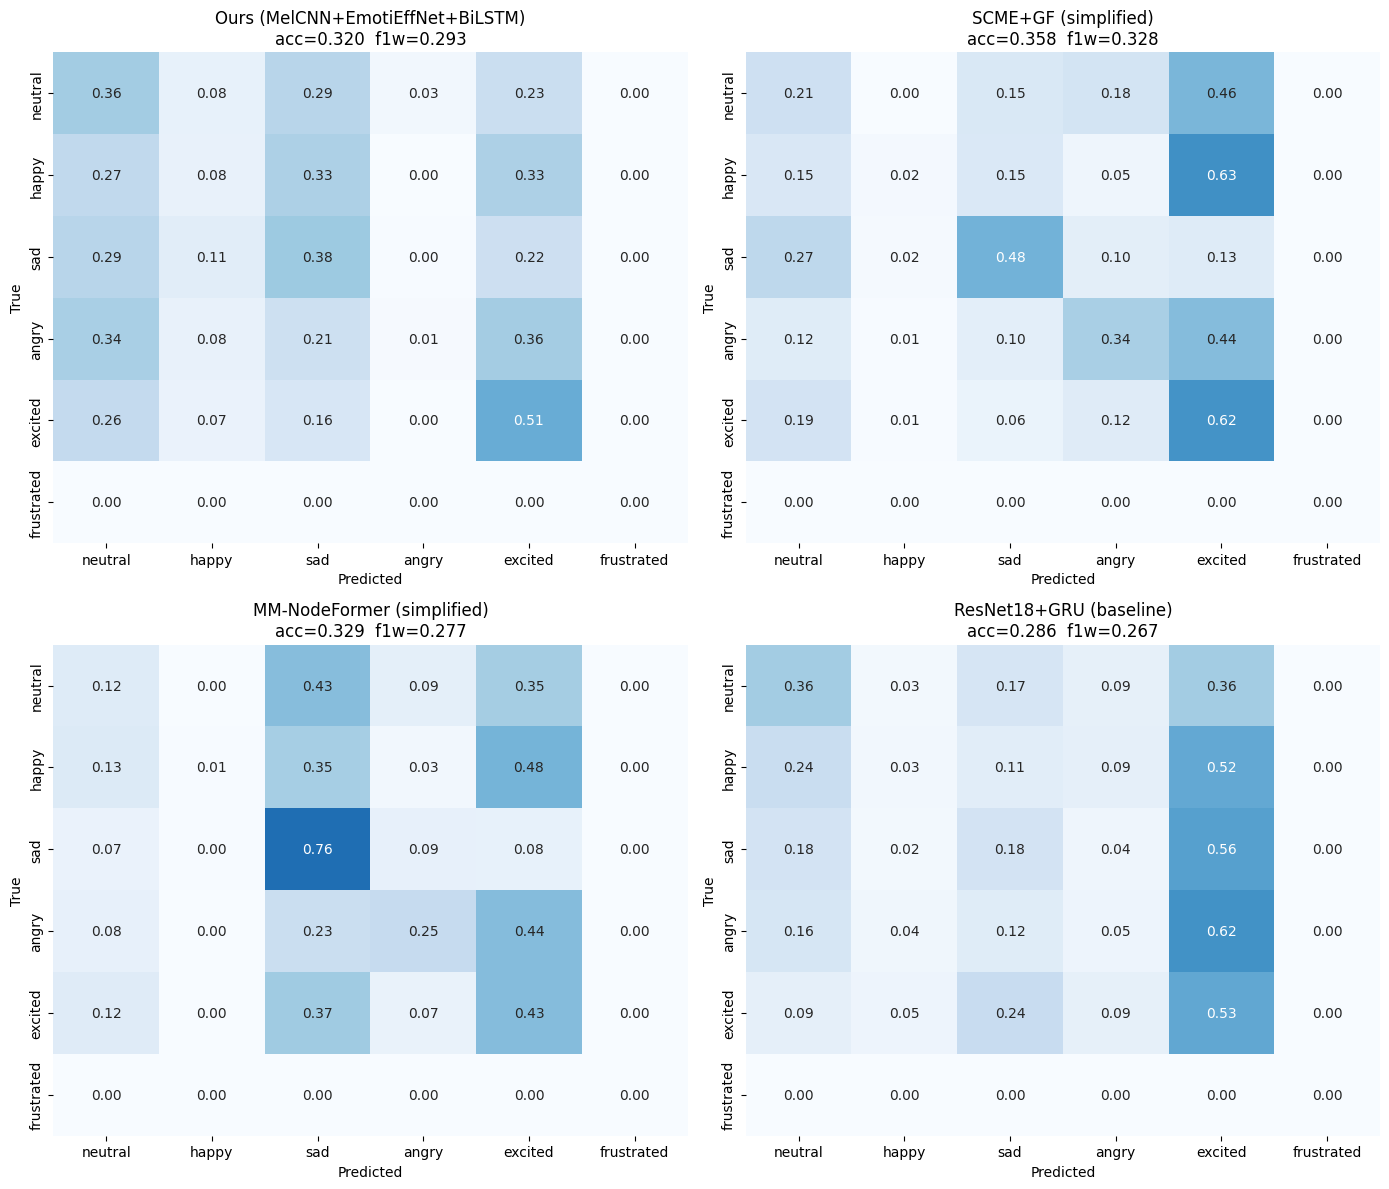

In [126]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
for ax, r in zip(axes.ravel(), all_res):
    cm = confusion_matrix(r['y_true'], r['y_pred'], labels=np.arange(N_CLS))
    cmn = cm.astype(float) / cm.sum(1, keepdims=True).clip(min=1)
    sns.heatmap(cmn, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=LABELS_6, yticklabels=LABELS_6,
                ax=ax, cbar=False, vmin=0, vmax=1)
    ax.set_title(f"{r['name']}\nacc={r['acc']:.3f}  f1w={r['f1w']:.3f}")
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
plt.tight_layout(); plt.show()

## 12. Сводная таблица


In [127]:
summary = pd.DataFrame([{
    'Model':       r['name'],
    'Accuracy':    round(r['acc'], 4),
    'F1 weighted': round(r['f1w'], 4),
    'ms/sample':   round(r['ms_per_sample'], 2),
    'Size (MB)':   round(r['size_mb'], 2),
} for r in all_res]).sort_values('F1 weighted', ascending=False)
print(summary.to_string(index=False))
summary.to_csv(CKPT_OUT_DIR / 'benchmark_results.csv', index=False)

                           Model  Accuracy  F1 weighted  ms/sample  Size (MB)
            SCME+GF (simplified)    0.3578       0.3284     607.89     379.13
Ours (MelCNN+EmotiEffNet+BiLSTM)    0.3199       0.2930     541.93      29.11
      MM-NodeFormer (simplified)    0.3288       0.2772     613.27     381.12
         ResNet18+GRU (baseline)    0.2861       0.2674     548.74      45.75


## 13. Визуальное сравнение моделей

Сводные графики по Accuracy, F1 weighted, инференсу (мс/сэмпл), размеру (MB) и trade-off F1↔скорость / F1↔размер.

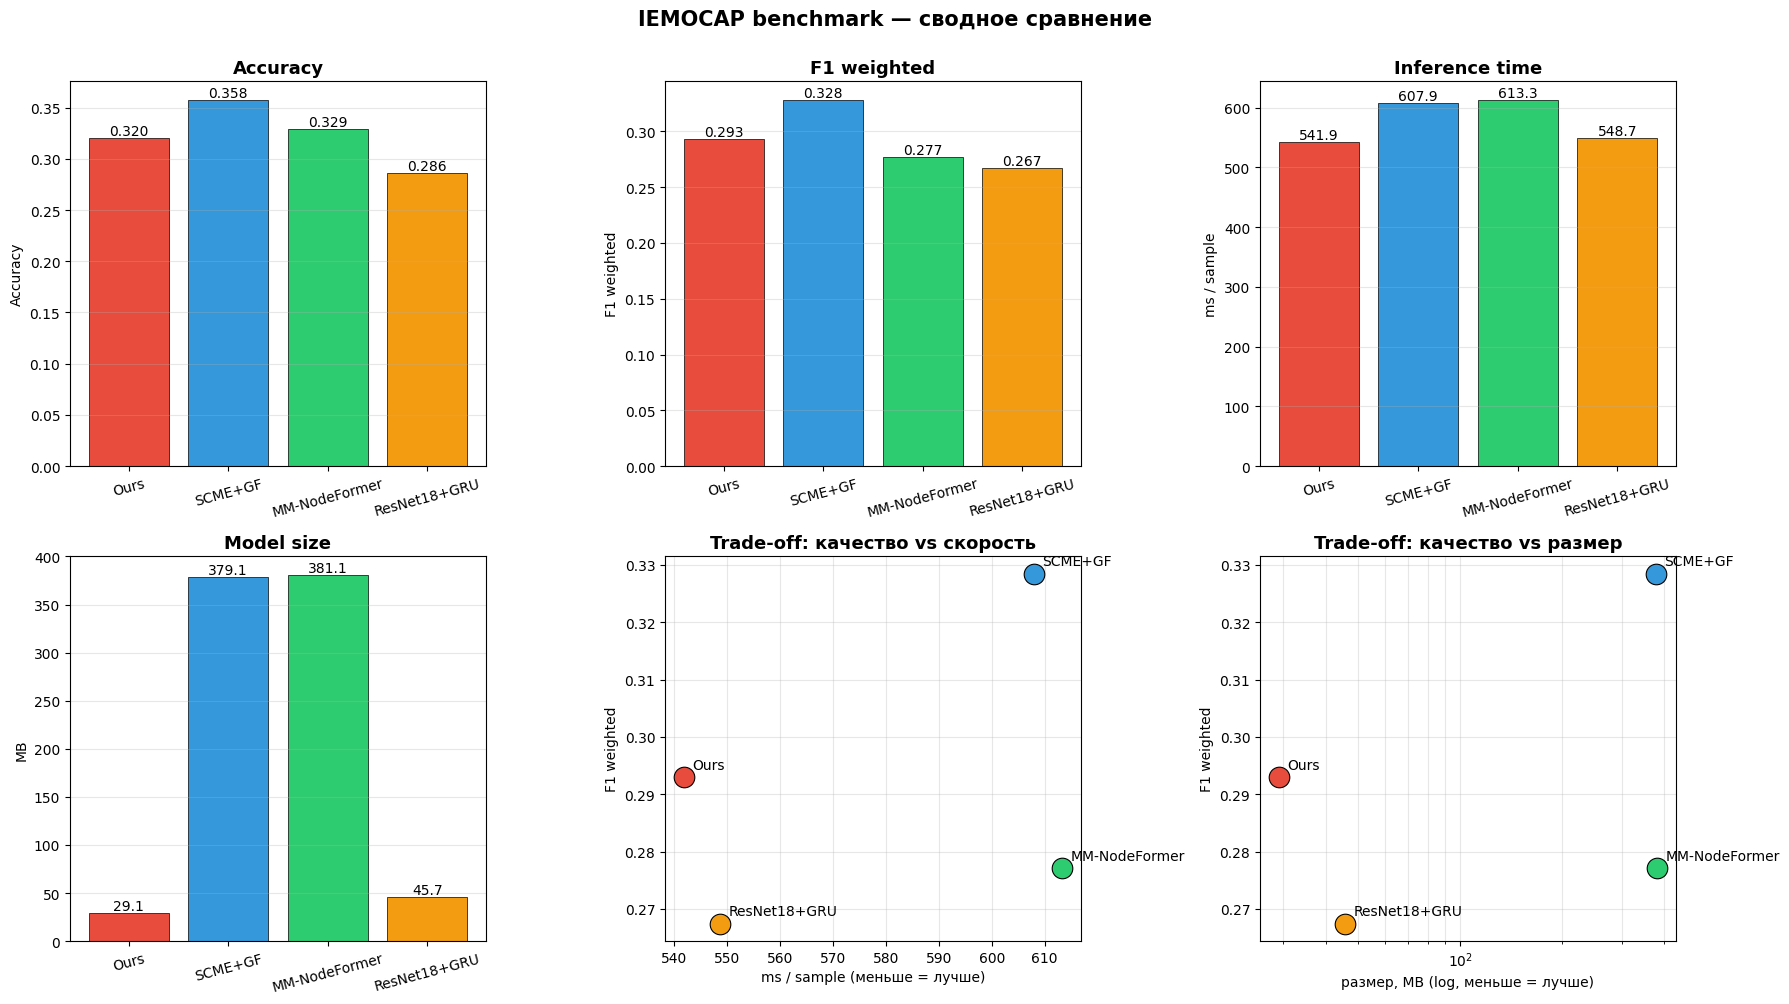

In [128]:
names  = [r['name']          for r in all_res]
accs   = [r['acc']           for r in all_res]
f1s    = [r['f1w']           for r in all_res]
times  = [r['ms_per_sample'] for r in all_res]
sizes  = [r['size_mb']       for r in all_res]

short = {
    'Ours (MelCNN+EmotiEffNet+BiLSTM)': 'Ours',
    'SCME+GF (simplified)':             'SCME+GF',
    'MM-NodeFormer (simplified)':       'MM-NodeFormer',
    'ResNet18+GRU (baseline)':          'ResNet18+GRU',
}
labels = [short.get(n, n) for n in names]
colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

def bar(ax, vals, title, ylabel, fmt='{:.3f}'):
    bars = ax.bar(labels, vals, color=colors, edgecolor='black', linewidth=0.5)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_ylabel(ylabel)
    ax.grid(axis='y', alpha=0.3)
    for b, v in zip(bars, vals):
        ax.text(b.get_x() + b.get_width()/2, b.get_height(), fmt.format(v),
                ha='center', va='bottom', fontsize=10)
    ax.tick_params(axis='x', rotation=15)

bar(axes[0, 0], accs,  'Accuracy',             'Accuracy')
bar(axes[0, 1], f1s,   'F1 weighted',          'F1 weighted')
bar(axes[0, 2], times, 'Inference time',       'ms / sample', fmt='{:.1f}')
bar(axes[1, 0], sizes, 'Model size',           'MB',          fmt='{:.1f}')

# trade-off: F1 vs speed (ниже-правее лучше по скорости, выше лучше по качеству)
ax = axes[1, 1]
for x, y, c, lab in zip(times, f1s, colors, labels):
    ax.scatter(x, y, s=220, c=c, edgecolor='black', linewidth=0.8, zorder=3)
    ax.annotate(lab, (x, y), xytext=(6, 6), textcoords='offset points', fontsize=10)
ax.set_xlabel('ms / sample (меньше = лучше)')
ax.set_ylabel('F1 weighted')
ax.set_title('Trade-off: качество vs скорость', fontsize=13, fontweight='bold')
ax.grid(alpha=0.3)

# trade-off: F1 vs size
ax = axes[1, 2]
for x, y, c, lab in zip(sizes, f1s, colors, labels):
    ax.scatter(x, y, s=220, c=c, edgecolor='black', linewidth=0.8, zorder=3)
    ax.annotate(lab, (x, y), xytext=(6, 6), textcoords='offset points', fontsize=10)
ax.set_xscale('log')
ax.set_xlabel('размер, MB (log, меньше = лучше)')
ax.set_ylabel('F1 weighted')
ax.set_title('Trade-off: качество vs размер', fontsize=13, fontweight='bold')
ax.grid(alpha=0.3, which='both')

plt.suptitle('IEMOCAP benchmark — сводное сравнение', fontsize=15, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig(CKPT_OUT_DIR / 'benchmark_summary.png', dpi=120, bbox_inches='tight')
plt.show()

## Заметки
- IEMOCAP `.avi` содержит двоих актёров в одном кадре; выбираем половину кадра по идентификатору говорящего в `utterance_id` перед детекцией лица.
- Признаки кешируются на диск (`datasets/iemocap_features_cache/*.pt`) — повторный прогон мгновенный.
- SCME+GF и MM-NodeFormer реализованы упрощённо и служат как приближения к оригинальным статьям.
